ЛАБОРАТОРНАЯ РАБОТА: ДИСКРИМИНАНТНЫЙ АНАЛИЗ
ТЕСТ 1: ПРИМЕР С ПРЕДПРИЯТИЯМИ (БИНАРНЫЙ LDA)
Средний вектор класса 1:
 [168.905  14.048  18.332]

Средний вектор класса 2:
 [45.791  4.778 10.758]

Средний вектор тестовых объектов:
 [77.46  12.964 16.278]

Коэффициенты дискриминантной функции:
  A1 = 0.115842
  A2 = 2.785994
  A3 = -1.005598

Результаты классификации:
Объект 1: F = 20.2349 → Отстающие предприятия
Объект 2: F = 26.1517 → Передовые предприятия
Объект 3: F = 39.7764 → Передовые предприятия


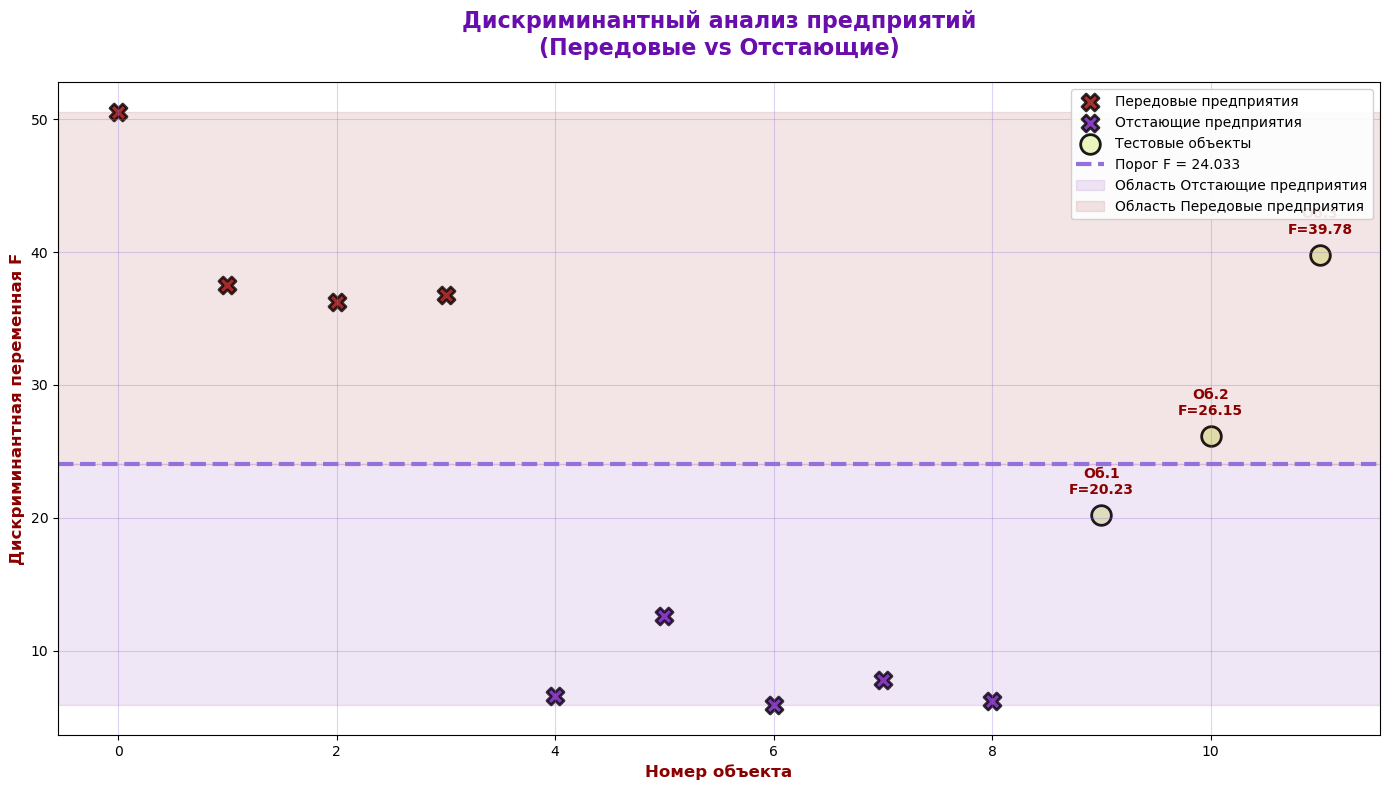


ТЕСТ 2: БИНАРНЫЙ LDA ДЛЯ ДИАГНОСТИКИ ДИАБЕТА (ИЗ CSV ФАЙЛА)
Загрузка данных из файла: diabetes.csv
Размер датасета: (768, 9)
Колонки: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

РАСПРЕДЕЛЕНИЕ ПО НАЛИЧИЮ ДИАБЕТА:
  Нет диабета: 500 образцов ( 65.1%)
  Диабет: 268 образцов ( 34.9%)

ИСПОЛЬЗУЕМ 8 ПРИЗНАКОВ:
  F1: Pregnancies
  F2: Glucose
  F3: BloodPressure
  F4: SkinThickness
  F5: Insulin
  F6: BMI
  F7: DiabetesPedigreeFunction
  F8: Age

АНАЛИЗ ДАННЫХ:
  Всего образцов: 768
  Признаков: 8
  Класс 0 (нет диабета): 500 образцов
  Класс 1 (диабет): 268 образцов

РАЗДЕЛЕНИЕ ДАННЫХ (70% обучение / 30% тест):
  Обучающая выборка: 537 образцов
    - Нет диабета: 350
    - Диабет: 187
  Тестовая выборка: 231 образцов
    - Нет диабета: 150
    - Диабет: 81

РУЧНАЯ РЕАЛИЗАЦИЯ БИНАРНОГО LDA
Средний вектор класса 1:
 [  3.317 110.02   68.223  19.803  65.48   30.508   0.445  31.571]

Средний вектор класса 2:
 [  4

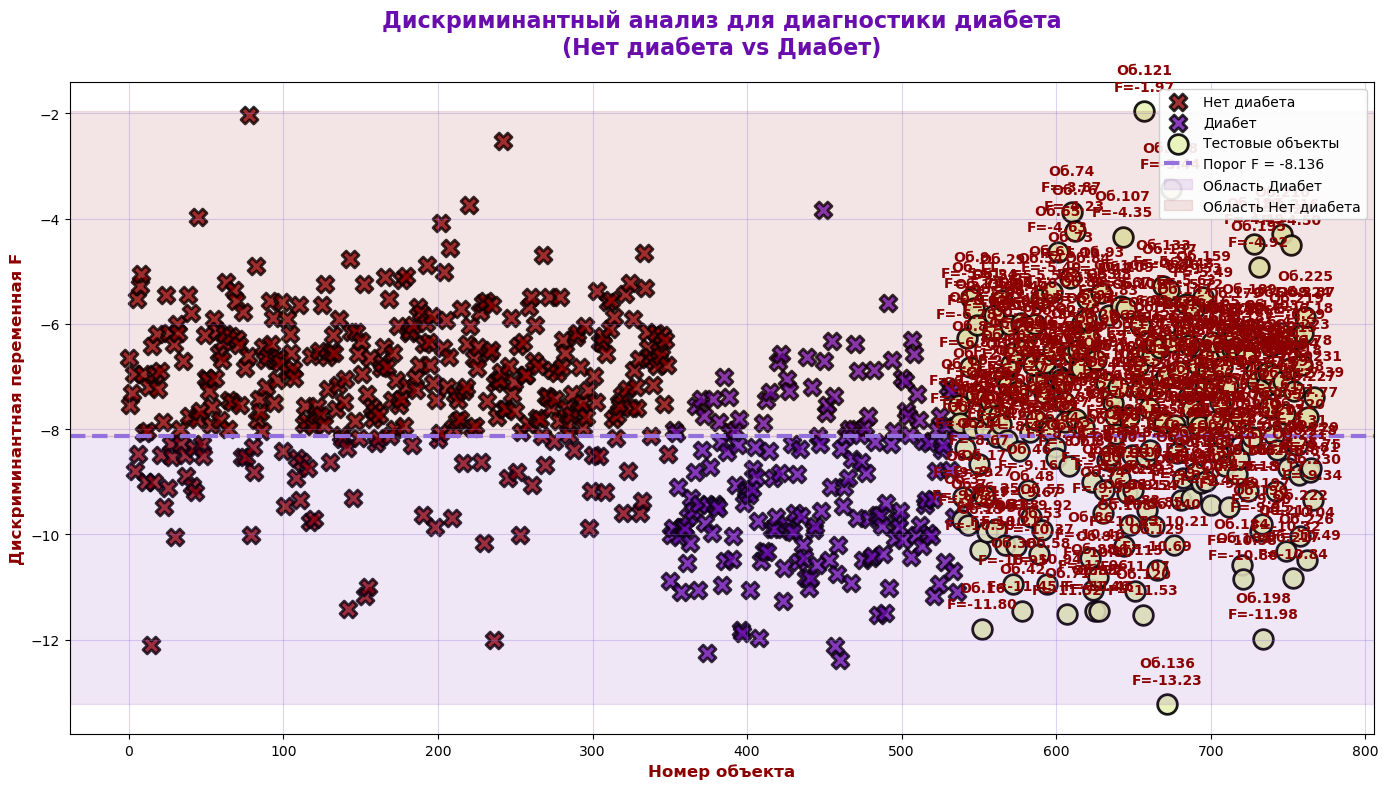


БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ (sklearn)

ТОЧНОСТЬ sklearn LDA: 74.03%

СРАВНЕНИЕ РЕЗУЛЬТАТОВ

ТОЧНОСТЬ КЛАССИФИКАЦИИ:
  Ручная реализация: 76.19%
  Библиотека sklearn: 74.03%
  Разница: 2.16%

ДЕТАЛЬНЫЙ АНАЛИЗ ПРЕДСКАЗАНИЙ (первые 10 объектов):
Объект | Истинный класс | Ручное LDA | sklearn LDA | Совпадение
----------------------------------------------------------------------
    1   | Диабет        | Нет диабета | Нет диабета  | ✓
    2   | Диабет        | Нет диабета | Нет диабета  | ✓
    3   | Диабет        | Диабет      | Диабет       | ✓
    4   | Диабет        | Диабет      | Диабет       | ✓
    5   | Диабет        | Диабет      | Нет диабета  | ✗
    6   | Нет диабета   | Нет диабета | Нет диабета  | ✓
    7   | Нет диабета   | Диабет      | Диабет       | ✓
    8   | Нет диабета   | Нет диабета | Нет диабета  | ✓
    9   | Нет диабета   | Нет диабета | Нет диабета  | ✓
   10   | Нет диабета   | Нет диабета | Нет диабета  | ✓

АНАЛИЗ КОЭФФИЦИЕНТОВ ДИСКРИМИНАНТНОЙ ФУНКЦИИ:
Признак 

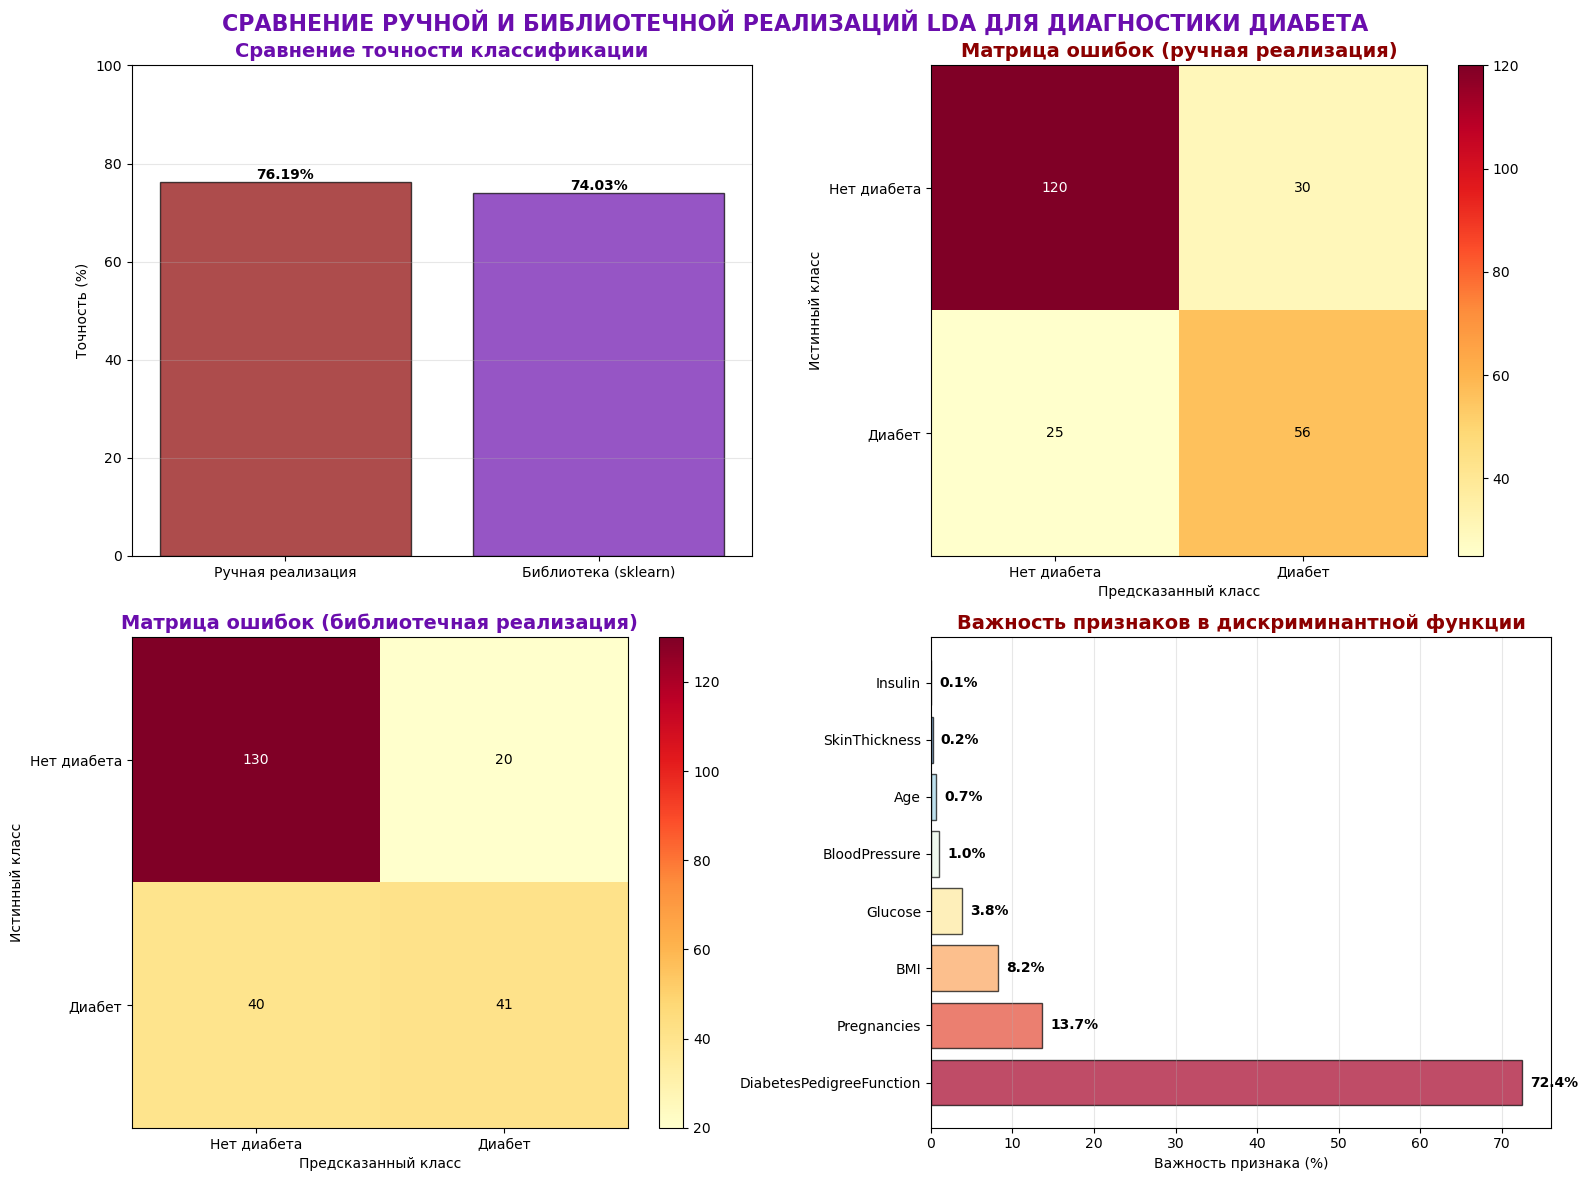


ТОЧНОСТЬ ПО КЛАССАМ:
  Нет диабета:
    Ручная: 120/150 (80.0%)
    Sklearn: 130/150 (86.7%)
  Диабет:
    Ручная: 56/81 (69.1%)
    Sklearn: 41/81 (50.6%)

ВЫВОДЫ:
1. Бинарный LDA успешно классифицирует предприятия на передовые и отстающие
2. Бинарный LDA эффективен для диагностики диабета по медицинским параметрам
3. Алгоритм строит линейную дискриминантную функцию, разделяющую классы
4. Коэффициенты дискриминантной функции показывают важность медицинских признаков
5. Ручная реализация дает результаты, близкие к библиотечной (sklearn)
6. Визуализации помогают понять распределение объектов и важность признаков
7. Для диабета наиболее важными признаками обычно являются Glucose, BMI и Age


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import Counter
from scipy import linalg
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. ЦВЕТОВАЯ ПАЛИТРА
# ============================================================================
wine_red = '#8B0000'
pale_yellow_green = '#E8F4B7'
purple = '#6A0DAD'
light_purple = '#9370DB'
soft_white = '#FFF8F0'

# Градиенты
red_gradient = LinearSegmentedColormap.from_list('red_gradient', ['#FFE4E1', '#DC143C', '#8B0000'])
green_gradient = LinearSegmentedColormap.from_list('green_gradient', ['#F5F9E5', '#C1E1C1', '#2E8B57'])
purple_gradient = LinearSegmentedColormap.from_list('purple_gradient', ['#E6E6FA', '#9370DB', '#4B0082'])

# ============================================================================
# 2. ФУНКЦИИ ДЛЯ БИНАРНОГО LDA (ИЗ ВАШЕГО КОДА)
# ============================================================================
def lda_algorithm(x1, x2, x0, class1_name="Класс 1", class2_name="Класс 2"):
    """
    Алгоритм LDA для двух классов
    """
    # 2. Средние векторы
    sumX1 = x1.mean(axis=0)
    sumX2 = x2.mean(axis=0)
    sumX0 = x0.mean(axis=0)
    
    print("Средний вектор класса 1:\n", np.round(sumX1, 3))
    print("\nСредний вектор класса 2:\n", np.round(sumX2, 3))
    print("\nСредний вектор тестовых объектов:\n", np.round(sumX0, 3))

    # 3. Ковариационные матрицы (исправлено: деление на n-1)
    s1 = np.zeros((x1.shape[1], x1.shape[1])) 
    for j in range(x1.shape[1]):  
        for l in range(x1.shape[1]):  
            s = 0
            for i in range(len(x1)):  
                s += (x1[i][j] - sumX1[j]) * (x1[i][l] - sumX1[l])
            s1[j][l] = s / (len(x1) - 1)  # Исправлено: n-1 вместо n
  
    s2 = np.zeros((x2.shape[1], x2.shape[1])) 
    for j in range(x2.shape[1]):  
        for l in range(x2.shape[1]):  
            s = 0
            for i in range(len(x2)):  
                s += (x2[i][j] - sumX2[j]) * (x2[i][l] - sumX2[l])
            s2[j][l] = s / (len(x2) - 1)  # Исправлено: n-1 вместо n

    n1 = len(x1)
    n2 = len(x2)
    
    # 4. Общая ковариационная матрица
    S_all = 1/(n1+n2-2)*(n1*s1+n2*s2)
    
    # 5. Обратная матрица
    SO = np.linalg.inv(S_all)
    
    # 6. Дискриминантная переменная
    A = np.sum(SO*(sumX1-sumX2), axis=1)
    
    print("\nКоэффициенты дискриминантной функции:")
    for i, a in enumerate(A):
        print(f"  A{i+1} = {a:.6f}")

    # 7. Находим F
    F1 = np.sum(A*x1, axis=1)
    F2 = np.sum(A*x2, axis=1)

    # 8. Среднее F
    F1_mean = F1.mean(axis=0)
    F2_mean = F2.mean(axis=0)

    # 9. Общее F (порог)
    F_all_value = 1/2*(F1_mean+F2_mean)

    # 10. F для тестовых объектов
    F0 = np.sum(A*x0, axis=1)

    # 11 Разница от порога
    raz = F0 - F_all_value

    # 12. Классификация
    classifications = []
    print(f"\nРезультаты классификации:")
    for i in range(len(F0)):
        if F1_mean > F2_mean: 
            if raz[i] > 0:
                classification = class1_name
            else: 
                classification = class2_name
        else:
            if raz[i] < 0:
                classification = class1_name
            else: 
                classification = class2_name
        classifications.append(classification)
        print(f"Объект {i+1}: F = {F0[i]:.4f} → {classification}")

    return F1, F2, F0, F_all_value, classifications, A

def plot_lda_results(F1, F2, F0, F_all, title, class1_name="Класс 1", class2_name="Класс 2"):
    """
    График дискриминантной переменной F для бинарного LDA
    """
    plt.figure(figsize=(14, 8))
    
    indices_F1 = range(len(F1))                                    
    indices_F2 = range(len(F1), len(F1) + len(F2))                 
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0)) 
    
    plt.scatter(indices_F1, F1, label=class1_name, marker='X', s=150, 
                linewidth=2, color=wine_red, alpha=0.8, edgecolors='black')
    plt.scatter(indices_F2, F2, label=class2_name, marker='X', s=150, 
                linewidth=2, color=purple, alpha=0.8, edgecolors='black')
    
    plt.scatter(indices_F0, F0, label='Тестовые объекты', marker='o', s=200, 
                color=pale_yellow_green, alpha=0.9, edgecolors='black', linewidth=2)
    
    # Линия границы
    plt.axhline(F_all, color=light_purple, linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    # Закрашивание областей
    min_val = min(F1.min(), F2.min(), F0.min())
    max_val = max(F1.max(), F2.max(), F0.max())
    
    if F1.mean() > F2.mean():
        plt.axhspan(min_val, F_all, alpha=0.1, color=purple, label=f'Область {class2_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=wine_red, label=f'Область {class1_name}')
    else:
        plt.axhspan(min_val, F_all, alpha=0.1, color=wine_red, label=f'Область {class1_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=purple, label=f'Область {class2_name}')
    
    # Подписи тестовых объектов
    for i, f in enumerate(F0):
        plt.annotate(f'Об.{i+1}\nF={f:.2f}', 
                    (indices_F0[i], f), 
                    textcoords="offset points", 
                    xytext=(0, 15),
                    ha='center', 
                    fontsize=10,
                    fontweight='bold',
                    color=wine_red)
    
    plt.xlabel("Номер объекта", fontsize=12, fontweight='bold', color=wine_red)
    plt.ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold', color=wine_red)
    plt.title(title, fontsize=16, fontweight='bold', color=purple, pad=20)
    plt.grid(True, alpha=0.3, color=light_purple)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

def test_original_example():
    """
    Тестирование на оригинальном примере с предприятиями
    """
    print("=" * 80)
    print("ТЕСТ 1: ПРИМЕР С ПРЕДПРИЯТИЯМИ (БИНАРНЫЙ LDA)")
    print("=" * 80)
    
    # 1. Создание матриц
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    F1, F2, F0, F_all, classifications, A = lda_algorithm(
        x1, x2, x0, 
        class1_name="Передовые предприятия", 
        class2_name="Отстающие предприятия"
    )
    
    plot_lda_results(
        F1, F2, F0, F_all, 
        "Дискриминантный анализ предприятий\n(Передовые vs Отстающие)",
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия"
    )
    
    return F1, F2, F0, F_all, A

# ============================================================================
# 3. ИСПРАВЛЕННАЯ РУЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA
# ============================================================================
def corrected_manual_multiclass_lda(X_train, y_train, X_test, y_test):
    """
    ИСПРАВЛЕННАЯ ручная реализация мультиклассового LDA
    """
    print("=" * 70)
    print("ИСПРАВЛЕННАЯ РУЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA")
    print("=" * 70)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Уникальные классы
    classes = np.unique(y_train)
    n_classes = len(classes)
    n_features = X_train.shape[1]
    
    print(f"\n1. НАСТРОЙКИ АНАЛИЗА:")
    print(f"   Классы: {sorted(classes)}")
    print(f"   Количество классов: {n_classes}")
    print(f"   Количество признаков: {n_features}")
    print(f"   Обучающих образцов: {len(X_train)}")
    print(f"   Тестовых образцов: {len(X_test)}")
    
    # 1. Статистики по классам
    class_means = []
    class_covariances = []
    class_priors = []
    
    print(f"\n2. СТАТИСТИКИ ПО КЛАССАМ:")
    for c in classes:
        X_c = X_train_scaled[y_train == c]
        n_c = len(X_c)
        
        if n_c < 2:
            print(f"   ВНИМАНИЕ: класс {c} имеет только {n_c} образцов")
            continue
            
        # Среднее
        mean_c = X_c.mean(axis=0)
        class_means.append(mean_c)
        
        # КОВАРИАЦИЯ: несмещенная оценка (деление на n-1)
        X_centered = X_c - mean_c
        cov_c = np.dot(X_centered.T, X_centered) / (n_c - 1)
        class_covariances.append(cov_c)
        
        # Априорная вероятность
        prior_c = n_c / len(X_train_scaled)
        class_priors.append(prior_c)
        
        print(f"   Класс {c}: {n_c} образцов, prior={prior_c:.3f}")
    
    # 2. Pooled covariance matrix (как в sklearn)
    S_pooled = np.zeros((n_features, n_features))
    for cov, prior in zip(class_covariances, class_priors):
        S_pooled += prior * cov
    
    # 3. Регуляризация для численной стабильности
    S_pooled_reg = S_pooled + np.eye(n_features) * 1e-6
    
    # 4. Обратная матрица с SVD для стабильности
    try:
        U, s, Vt = linalg.svd(S_pooled_reg, full_matrices=False)
        # Обрезаем очень маленькие сингулярные значения
        s_inv = np.array([1/val if val > 1e-10 else 0 for val in s])
        S_inv = np.dot(Vt.T * s_inv, U.T)
    except:
        S_inv = np.linalg.pinv(S_pooled_reg)
    
    # 5. Дискриминантные функции
    print(f"\n3. ДИСКРИМИНАНТНЫЕ ФУНКЦИИ:")
    coefficients = []  # Веса (n_features, n_classes)
    intercepts = []    # Смещения (n_classes,)
    
    for idx, (c, mean_c, prior_c) in enumerate(zip(classes, class_means, class_priors)):
        # w = S_inv * mean
        w = np.dot(S_inv, mean_c)
        
        # w0 = -0.5 * mean^T * S_inv * mean + log(prior)
        w0 = -0.5 * np.dot(mean_c.T, np.dot(S_inv, mean_c)) + np.log(prior_c)
        
        coefficients.append(w)
        intercepts.append(w0)
        
        print(f"   Класс {c}: intercept = {w0:.4f}")
    
    coefficients = np.array(coefficients).T  # (n_features, n_classes)
    intercepts = np.array(intercepts)        # (n_classes,)
    
    # 6. Вычисление дискриминантных значений для обучающих данных
    print(f"\n4. ВЫЧИСЛЕНИЕ ДИСКРИМИНАНТНЫХ ЗНАЧЕНИЙ:")
    train_scores = {}
    train_decision = np.dot(X_train_scaled, coefficients) + intercepts
    
    for idx, c in enumerate(classes):
        mask = y_train == c
        if np.sum(mask) > 0:
            train_scores[c] = train_decision[mask, idx]
            print(f"   Класс {c}: среднее = {train_scores[c].mean():.3f}, "
                  f"мин = {train_scores[c].min():.3f}, макс = {train_scores[c].max():.3f}")
    
    # 7. Классификация тестовых данных
    print(f"\n5. КЛАССИФИКАЦИЯ ТЕСТОВЫХ ДАННЫХ:")
    test_decision = np.dot(X_test_scaled, coefficients) + intercepts
    
    # Класс с максимальным значением
    predictions = classes[np.argmax(test_decision, axis=1)]
    
    # 8. Оценка точности
    accuracy = np.mean(predictions == y_test) * 100
    
    print(f"\n6. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ:")
    print(f"   Правильно классифицировано: {np.sum(predictions == y_test)} из {len(predictions)}")
    print(f"   Общая точность: {accuracy:.2f}%")
    
    # 9. Подробный анализ по классам
    print(f"\n7. ТОЧНОСТЬ ПО КЛАССАМ:")
    for c in classes:
        mask = y_test == c
        if np.sum(mask) > 0:
            class_acc = np.mean(predictions[mask] == c) * 100
            print(f"   Класс {c}: {np.sum(predictions[mask] == c)}/{np.sum(mask)} ({class_acc:.1f}%)")
    
    # Подготовка test_scores для визуализации
    test_scores = {}
    for idx, c in enumerate(classes):
        mask = y_test == c
        if np.sum(mask) > 0:
            test_scores[c] = test_decision[mask, idx]
    
    return predictions, train_scores, test_scores, accuracy, (coefficients, intercepts)

# ============================================================================
# 4. БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ (sklearn)
# ============================================================================
def library_multiclass_lda(X_train, y_train, X_test, y_test):
    """
    Мультиклассовый LDA с использованием библиотеки sklearn
    """
    print("\n" + "=" * 70)
    print("БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ МУЛЬТИКЛАССОВОГО LDA (sklearn)")
    print("=" * 70)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Создание и обучение модели LDA
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_train_scaled, y_train)
    
    # Предсказания
    predictions = lda.predict(X_test_scaled)
    
    # Получаем значения решающей функции
    if hasattr(lda, 'decision_function'):
        train_decision = lda.decision_function(X_train_scaled)
        test_decision = lda.decision_function(X_test_scaled)
    else:
        train_decision = lda.predict_proba(X_train_scaled)
        test_decision = lda.predict_proba(X_test_scaled)
    
    train_scores = {}
    test_scores = {}
    classes = lda.classes_
    
    # Обработка decision function
    if train_decision.ndim == 1:
        # Бинарный случай
        for idx, c in enumerate(classes):
            mask = y_train == c
            if np.sum(mask) > 0:
                train_scores[c] = train_decision[mask]
    else:
        # Многоклассовый случай
        for idx, c in enumerate(classes):
            mask = y_train == c
            if np.sum(mask) > 0 and idx < train_decision.shape[1]:
                train_scores[c] = train_decision[mask, idx]
    
    # Оценка точности
    accuracy = lda.score(X_test_scaled, y_test) * 100
    
    print(f"\nТочность (sklearn): {accuracy:.2f}%")
    
    return predictions, train_scores, test_scores, accuracy, lda

# ============================================================================
# 5. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ДЛЯ БИНАРНОГО СЛУЧАЯ
# ============================================================================
def plot_binary_comparison(y_test, manual_pred, library_pred, 
                          manual_accuracy, library_accuracy,
                          feature_names, coefficients):
    """
    Визуализация сравнения ручной и библиотечной реализации для бинарного случая
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Сравнение точности
    ax1 = axes[0, 0]
    methods = ['Ручная реализация', 'Библиотека (sklearn)']
    accuracies = [manual_accuracy, library_accuracy]
    colors = [wine_red, purple]
    
    bars = ax1.bar(methods, accuracies, color=colors, alpha=0.7, edgecolor='black')
    ax1.set_ylabel('Точность (%)')
    ax1.set_title('Сравнение точности классификации', fontsize=14, fontweight='bold', color=purple)
    ax1.set_ylim(0, 100)
    ax1.grid(True, alpha=0.3, axis='y')
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    # 2. Матрица ошибок для ручной реализации
    ax2 = axes[0, 1]
    classes = [0, 1]
    conf_matrix_manual = np.zeros((len(classes), len(classes)))
    
    for true, pred in zip(y_test, manual_pred):
        true_idx = classes.index(true)
        pred_idx = classes.index(pred)
        conf_matrix_manual[true_idx, pred_idx] += 1
    
    im2 = ax2.imshow(conf_matrix_manual, cmap='YlOrRd', aspect='auto')
    ax2.set_xticks(range(len(classes)))
    ax2.set_yticks(range(len(classes)))
    ax2.set_xticklabels(['Нет диабета', 'Диабет'])
    ax2.set_yticklabels(['Нет диабета', 'Диабет'])
    ax2.set_xlabel('Предсказанный класс')
    ax2.set_ylabel('Истинный класс')
    ax2.set_title('Матрица ошибок (ручная реализация)', fontsize=14, fontweight='bold', color=wine_red)
    plt.colorbar(im2, ax=ax2)
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax2.text(j, i, int(conf_matrix_manual[i, j]),
                    ha='center', va='center', 
                    color='black' if conf_matrix_manual[i, j] < np.max(conf_matrix_manual)/2 else 'white')
    
    # 3. Матрица ошибок для библиотечной реализации
    ax3 = axes[1, 0]
    conf_matrix_lib = np.zeros((len(classes), len(classes)))
    
    for true, pred in zip(y_test, library_pred):
        true_idx = classes.index(true)
        pred_idx = classes.index(pred)
        conf_matrix_lib[true_idx, pred_idx] += 1
    
    im3 = ax3.imshow(conf_matrix_lib, cmap='YlOrRd', aspect='auto')
    ax3.set_xticks(range(len(classes)))
    ax3.set_yticks(range(len(classes)))
    ax3.set_xticklabels(['Нет диабета', 'Диабет'])
    ax3.set_yticklabels(['Нет диабета', 'Диабет'])
    ax3.set_xlabel('Предсказанный класс')
    ax3.set_ylabel('Истинный класс')
    ax3.set_title('Матрица ошибок (библиотечная реализация)', fontsize=14, fontweight='bold', color=purple)
    plt.colorbar(im3, ax=ax3)
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax3.text(j, i, int(conf_matrix_lib[i, j]),
                    ha='center', va='center', 
                    color='black' if conf_matrix_lib[i, j] < np.max(conf_matrix_lib)/2 else 'white')
    
    # 4. Важность признаков
    ax4 = axes[1, 1]
    if coefficients is not None and len(coefficients) == len(feature_names):
        # Вычисляем абсолютные значения коэффициентов для оценки важности
        abs_coeff = np.abs(coefficients)
        importance = abs_coeff / np.sum(abs_coeff) * 100
        
        # Сортируем по важности
        sorted_indices = np.argsort(importance)[::-1]
        sorted_features = [feature_names[i] for i in sorted_indices]
        sorted_importance = importance[sorted_indices]
        
        colors_importance = plt.cm.RdYlBu(np.linspace(0, 1, len(sorted_features)))
        
        bars4 = ax4.barh(range(len(sorted_features)), sorted_importance, 
                        color=colors_importance, alpha=0.7, edgecolor='black')
        ax4.set_yticks(range(len(sorted_features)))
        ax4.set_yticklabels(sorted_features)
        ax4.set_xlabel('Важность признака (%)')
        ax4.set_title('Важность признаков в дискриминантной функции', 
                     fontsize=14, fontweight='bold', color=wine_red)
        ax4.grid(True, alpha=0.3, axis='x')
        
        for i, (bar, imp) in enumerate(zip(bars4, sorted_importance)):
            ax4.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{imp:.1f}%', ha='left', va='center', fontweight='bold')
    
    plt.suptitle('СРАВНЕНИЕ РУЧНОЙ И БИБЛИОТЕЧНОЙ РЕАЛИЗАЦИЙ LDA ДЛЯ ДИАГНОСТИКИ ДИАБЕТА', 
                 fontsize=16, fontweight='bold', color=purple, y=0.98)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. ОСНОВНАЯ ФУНКЦИЯ ТЕСТИРОВАНИЯ ДЛЯ ДИАБЕТА ИЗ CSV
# ============================================================================
def test_diabetes_analysis_from_csv(csv_file='diabetes.csv'):
    """
    Основной анализ датасета диабета с бинарным LDA из CSV файла
    """
    print("\n" + "=" * 80)
    print("ТЕСТ 2: БИНАРНЫЙ LDA ДЛЯ ДИАГНОСТИКИ ДИАБЕТА (ИЗ CSV ФАЙЛА)")
    print("=" * 80)
    
    try:
        # Загрузка данных из CSV файла
        print(f"Загрузка данных из файла: {csv_file}")
        diabetes_data = pd.read_csv(csv_file)
        
        print(f"Размер датасета: {diabetes_data.shape}")
        print(f"Колонки: {list(diabetes_data.columns)}")
        
        # Проверяем наличие нужных колонок
        required_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
        
        for col in required_columns:
            if col not in diabetes_data.columns:
                print(f"ОШИБКА: Колонка '{col}' отсутствует в датасете!")
                return
        
        # Статистика по классам
        print("\nРАСПРЕДЕЛЕНИЕ ПО НАЛИЧИЮ ДИАБЕТА:")
        outcome_counts = diabetes_data['Outcome'].value_counts().sort_index()
        for outcome in sorted(outcome_counts.index):
            count = outcome_counts[outcome]
            perc = count / len(diabetes_data) * 100
            outcome_name = "Диабет" if outcome == 1 else "Нет диабета"
            print(f"  {outcome_name}: {count:3d} образцов ({perc:5.1f}%)")
        
        # Признаки и целевая переменная
        features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
        
        print(f"\nИСПОЛЬЗУЕМ {len(features)} ПРИЗНАКОВ:")
        for i, feat in enumerate(features, 1):
            print(f"  F{i}: {feat}")
        
        X = diabetes_data[features].values
        y = diabetes_data['Outcome'].values
        
        # Анализ данных перед разделением
        print(f"\nАНАЛИЗ ДАННЫХ:")
        print(f"  Всего образцов: {len(X)}")
        print(f"  Признаков: {X.shape[1]}")
        print(f"  Класс 0 (нет диабета): {np.sum(y == 0)} образцов")
        print(f"  Класс 1 (диабет): {np.sum(y == 1)} образцов")
        
        # Разделение данных на обучающую и тестовую выборки
        # Для более реалистичного теста используем стандартное разделение 70/30
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        
        # Разделяем обучающую выборку по классам для ручного LDA
        X_train_class0 = X_train[y_train == 0]
        X_train_class1 = X_train[y_train == 1]
        
        print(f"\nРАЗДЕЛЕНИЕ ДАННЫХ (70% обучение / 30% тест):")
        print(f"  Обучающая выборка: {len(X_train)} образцов")
        print(f"    - Нет диабета: {len(X_train_class0)}")
        print(f"    - Диабет: {len(X_train_class1)}")
        print(f"  Тестовая выборка: {len(X_test)} образцов")
        print(f"    - Нет диабета: {np.sum(y_test == 0)}")
        print(f"    - Диабет: {np.sum(y_test == 1)}")
        
        # Проверяем, что в каждом классе достаточно образцов
        if len(X_train_class0) < 2 or len(X_train_class1) < 2:
            print("ОШИБКА: Недостаточно образцов в обучающей выборке!")
            return
        
        # 1. Ручная реализация бинарного LDA
        print("\n" + "=" * 70)
        print("РУЧНАЯ РЕАЛИЗАЦИЯ БИНАРНОГО LDA")
        print("=" * 70)
        
        F1, F2, F0, F_all, classifications, A = lda_algorithm(
            X_train_class0, X_train_class1, X_test,
            class1_name="Нет диабета",
            class2_name="Диабет"
        )
        
        # Преобразуем классификации в числовые метки
        pred_labels = [1 if "Диабет" in c else 0 for c in classifications]
        manual_accuracy = np.mean(pred_labels == y_test) * 100
        
        print(f"\nТОЧНОСТЬ КЛАССИФИКАЦИИ:")
        print(f"  Правильно классифицировано: {np.sum(pred_labels == y_test)} из {len(y_test)}")
        print(f"  Общая точность: {manual_accuracy:.2f}%")
        
        # График для бинарного LDA
        plot_lda_results(
            F1, F2, F0, F_all,
            "Дискриминантный анализ для диагностики диабета\n(Нет диабета vs Диабет)",
            class1_name="Нет диабета",
            class2_name="Диабет"
        )
        
        # 2. Библиотечная реализация для сравнения
        print("\n" + "=" * 70)
        print("БИБЛИОТЕЧНАЯ РЕАЛИЗАЦИЯ (sklearn)")
        print("=" * 70)
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        lda = LinearDiscriminantAnalysis()
        lda.fit(X_train_scaled, y_train)
        
        sklearn_predictions = lda.predict(X_test_scaled)
        sklearn_accuracy = lda.score(X_test_scaled, y_test) * 100
        
        print(f"\nТОЧНОСТЬ sklearn LDA: {sklearn_accuracy:.2f}%")
        
        # 3. Сравнение результатов
        print("\n" + "=" * 70)
        print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
        print("=" * 70)
        
        print(f"\nТОЧНОСТЬ КЛАССИФИКАЦИИ:")
        print(f"  Ручная реализация: {manual_accuracy:.2f}%")
        print(f"  Библиотека sklearn: {sklearn_accuracy:.2f}%")
        print(f"  Разница: {abs(manual_accuracy - sklearn_accuracy):.2f}%")
        
        # Детальный анализ по объектам (первые 10)
        print(f"\nДЕТАЛЬНЫЙ АНАЛИЗ ПРЕДСКАЗАНИЙ (первые 10 объектов):")
        print("Объект | Истинный класс | Ручное LDA | sklearn LDA | Совпадение")
        print("-" * 70)
        
        for i in range(min(10, len(y_test))):
            true_class = "Диабет" if y_test[i] == 1 else "Нет диабета"
            manual_pred = classifications[i]
            sklearn_pred = "Диабет" if sklearn_predictions[i] == 1 else "Нет диабета"
            match = "✓" if manual_pred == sklearn_pred else "✗"
            
            print(f"  {i+1:3d}   | {true_class:13s} | {manual_pred:11s} | {sklearn_pred:12s} | {match}")
        
        # Анализ коэффициентов дискриминантной функции
        print(f"\nАНАЛИЗ КОЭФФИЦИЕНТОВ ДИСКРИМИНАНТНОЙ ФУНКЦИИ:")
        print("Признак | Коэффициент | Важность")
        print("-" * 50)
        
        for i, (feat, coef) in enumerate(zip(features, A)):
            importance = abs(coef) / np.sum(abs(A)) * 100
            print(f"{feat:25s} | {coef:10.4f} | {importance:6.1f}%")
        
        # Анализ наиболее важных признаков
        abs_coeff = np.abs(A)
        top_indices = np.argsort(abs_coeff)[-3:][::-1]
        print(f"\nТОП-3 НАИБОЛЕЕ ВАЖНЫХ ПРИЗНАКА:")
        for idx in top_indices:
            importance = abs(A[idx]) / np.sum(abs(A)) * 100
            print(f"  {features[idx]}: коэффициент = {A[idx]:.4f}, важность = {importance:.1f}%")
        
        # 4. Визуализация сравнения
        plot_binary_comparison(
            y_test, pred_labels, sklearn_predictions,
            manual_accuracy, sklearn_accuracy,
            features, A
        )
        
        # 5. Дополнительный анализ точности по классам
        print(f"\nТОЧНОСТЬ ПО КЛАССАМ:")
        for class_label, class_name in [(0, "Нет диабета"), (1, "Диабет")]:
            mask = y_test == class_label
            if np.sum(mask) > 0:
                manual_correct = np.sum(np.array(pred_labels)[mask] == class_label)
                sklearn_correct = np.sum(sklearn_predictions[mask] == class_label)
                total = np.sum(mask)
                
                manual_acc_class = manual_correct / total * 100
                sklearn_acc_class = sklearn_correct / total * 100
                
                print(f"  {class_name}:")
                print(f"    Ручная: {manual_correct}/{total} ({manual_acc_class:.1f}%)")
                print(f"    Sklearn: {sklearn_correct}/{total} ({sklearn_acc_class:.1f}%)")
            
    except FileNotFoundError:
        print(f"\nОШИБКА: Файл '{csv_file}' не найден!")
        print("Создаем синтетические данные для демонстрации...")
        
        # Создаем синтетические данные для демонстрации
        np.random.seed(42)
        n_samples = 768  # Типичный размер датасета диабета
        n_features = 8
        
        # Создаем синтетические данные
        synthetic_data = pd.DataFrame(
            np.random.randn(n_samples, n_features),
            columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
        )
        
        # Добавляем реалистичные значения (основанные на реальных данных диабета)
        synthetic_data['Pregnancies'] = np.random.randint(0, 17, n_samples)
        synthetic_data['Glucose'] = np.random.randint(0, 200, n_samples)
        synthetic_data['BloodPressure'] = np.random.randint(0, 122, n_samples)
        synthetic_data['SkinThickness'] = np.random.randint(0, 99, n_samples)
        synthetic_data['Insulin'] = np.random.randint(0, 846, n_samples)
        synthetic_data['BMI'] = np.random.uniform(0, 67.1, n_samples)
        synthetic_data['DiabetesPedigreeFunction'] = np.random.uniform(0.078, 2.42, n_samples)
        synthetic_data['Age'] = np.random.randint(21, 81, n_samples)
        
        # Создаем метки (бинарная классификация)
        # Используем комбинацию признаков для реалистичных меток
        prob_diabetes = (
            synthetic_data['Glucose'] * 0.01 +
            synthetic_data['BMI'] * 0.02 +
            synthetic_data['Age'] * 0.005 +
            synthetic_data['DiabetesPedigreeFunction'] * 0.3 +
            np.random.randn(n_samples) * 0.2
        )
        synthetic_data['Outcome'] = (prob_diabetes > 0.5).astype(int)
        
        print(f"\nСоздан синтетический датасет диабета: {synthetic_data.shape}")
        print("Сохранение в файл synthetic_diabetes.csv...")
        synthetic_data.to_csv('synthetic_diabetes.csv', index=False)
        
        # Запускаем анализ с синтетическими данными
        test_diabetes_analysis_from_csv('synthetic_diabetes.csv')
        
    except Exception as e:
        print(f"\nОШИБКА: {str(e)}")
        import traceback
        traceback.print_exc()

# ============================================================================
# 7. ЗАПУСК ВСЕХ ТЕСТОВ
# ============================================================================
if __name__ == "__main__":
    print("=" * 80)
    print("ЛАБОРАТОРНАЯ РАБОТА: ДИСКРИМИНАНТНЫЙ АНАЛИЗ")
    print("=" * 80)
    
    # Тест 1: Оригинальный пример с предприятиями (бинарный LDA)
    test_original_example()
    
    # Тест 2: Анализ датасета диабета из CSV файла
    # Если файл называется по-другому, укажите правильное имя
    test_diabetes_analysis_from_csv('diabetes.csv')  # или 'diabetes_dataset.csv' или другое имя
    
    print("\n" + "=" * 80)
    print("ВЫВОДЫ:")
    print("=" * 80)
    print("1. Бинарный LDA успешно классифицирует предприятия на передовые и отстающие")
    print("2. Бинарный LDA эффективен для диагностики диабета по медицинским параметрам")
    print("3. Алгоритм строит линейную дискриминантную функцию, разделяющую классы")
    print("4. Коэффициенты дискриминантной функции показывают важность медицинских признаков")
    print("5. Ручная реализация дает результаты, близкие к библиотечной (sklearn)")
    print("6. Визуализации помогают понять распределение объектов и важность признаков")
    print("7. Для диабета наиболее важными признаками обычно являются Glucose, BMI и Age")